In [1]:
import os
from pathlib import Path
import torch
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

import dualneuron
from dualneuron.screening.sets import RenderedImages, ImagenetImages
from dualneuron.twins.nets import load_model, model_summary
from dualneuron.synthesis.ascend import fourier_ascending, pixel_ascending
from dualneuron.synthesis.visualize import blend, plot_group
from dualneuron.synthesis.objectives import response_objective

from dualneuron.analysis.pca import (
    extract_population_responses, 
    fit_pca, 
    get_pc_vector,
    interpolate_pc,
    interpolate_pc_2d,
    plot_pca_variance
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
token = os.getenv("HF_TOKEN")
data_dir = os.getenv("DATA_DIR")

In [2]:
architecture = 'v4'
dataset = "imagenet"
layer = None

layer_name = layer if layer is not None else "output"
idx_dir = data_dir + f"dryad/{architecture}_{layer_name}_{dataset}_ordered_indices"

if architecture == 'v4':
    model_name = "V4ColorTaskDriven"
    use_grayscale = False
    num_channels = 3
    output_size = (100, 100)
    
elif architecture == 'v4g':
    model_name = "V4GrayTaskDriven"
    use_grayscale = True
    num_channels = 1
    output_size = (100, 100)
    
elif architecture == 'v1':
    model_name = "V1GrayTaskDriven"
    use_grayscale = True
    num_channels = 1
    output_size = (93, 93)

package_dir = Path(dualneuron.__file__).parent
mask_path = package_dir / "twins" / model_name / "mask.npy"
mask = np.load(mask_path)

if dataset == "rendered":
    dset = RenderedImages( 
        data_dir=data_dir + "rendered_data",
        # Transform options
        use_center_crop=True,
        use_resize_output=True,
        use_grayscale=use_grayscale,
        use_normalize=False,
        use_mask=False,
        use_crop_to_mask=False,
        use_norm=False,
        use_clip=False,
        # Transform parameters
        mask=mask,
        num_channels=num_channels,
        output_size=(224, 224),
        crop_size=236,
        bg_value=0.0,
        clip_min=0.0,
        clip_max=1.0,
        crop_padding_frac=0.1,
        norm=None,
    )
elif dataset == "imagenet":
    dset = ImagenetImages(
        data_dir=data_dir + "datasets",
        token=token,
        split='train',
        # Transform options
        use_center_crop=True,
        use_resize_output=True,
        use_grayscale=False,
        use_normalize=False,
        use_mask=False,
        use_crop_to_mask=False,
        use_norm=False,
        use_clip=False,
        # Transform parameters
        mask=mask,
        num_channels=3,
        output_size=(224, 224),
        crop_size=236,
        bg_value=0.0,
        clip_min=0.0,
        clip_max=1.0,
        crop_padding_frac=0.1,
        norm=None,
    )

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/267 [00:00<?, ?it/s]

In [3]:
from dualneuron.screening.utils import get_pole_indices

M = 250
neuron = 6
indices_path = os.path.join(idx_dir, f"{neuron}.npy")
pole_idx = get_pole_indices(indices_path, m=M)
indices = np.concatenate([pole_idx['low'], pole_idx['high']])

In [4]:
if False:
    model, hooks = model_summary(
        architecture=architecture, 
        input_size=(1, 3, 100, 100), 
        device='cuda'
    )

function = load_model(
    architecture="dreamsim", 
    layer=None, 
    ensemble=False, 
    centered=True, 
    untrained=False,
    device='cuda',
    cache_dir=data_dir + "dreamsim_models"
)

Using cached /dj-stor01/pipeline-externals/pipeline_bipolar/dreamsim_models


Using cache found in /dj-stor01/pipeline-externals/pipeline_bipolar/dreamsim_models/facebookresearch_dino_main


In [5]:
responses, indices = extract_population_responses(
    model=function.embed,
    dataset=dset,
    batch_size=64,
    num_images=2000,
    indices=indices,
    device='cuda',
    seed=42,
    model_kwargs={}
)

Extracting responses: 100%|██████████| 8/8 [00:20<00:00,  2.51s/it]


In [6]:
pca_result = fit_pca(responses, n_components=6, center=True, device='cuda')
pca_result['explained_variance_ratio']

array([0.06179904, 0.05688604, 0.02785689, 0.02613107, 0.02131469,
       0.01997687], dtype=float32)

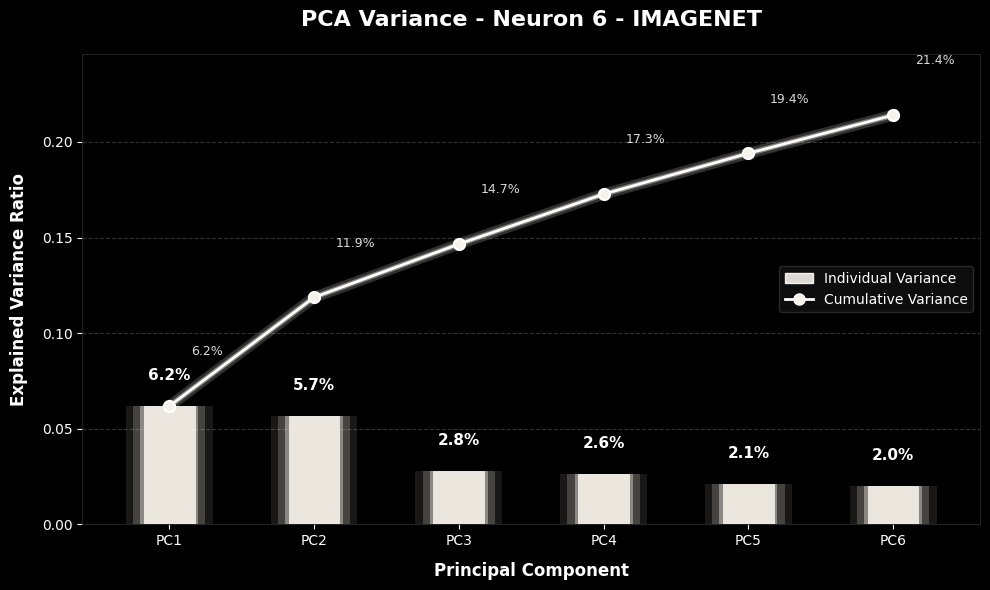

In [7]:
plot_pca_variance(
    pca_result['explained_variance_ratio'], 
    accent_color="#F6F1E9", 
    title_prefix=f"PCA Variance - Neuron {neuron} - {dataset.upper()}"
)

In [18]:
results = []
grid = interpolate_pc_2d(pca_result, pc_indices=(0, 1), n_steps=5, range_std=2.0)

for i, c1 in tqdm(enumerate(grid['coords_1'])):
    for j, c2 in enumerate(grid['coords_2']):
        target = grid['responses'][i][j]
        obj = response_objective(
            function.embed, 
            target=target, 
            mode='reconstruct', 
            sign=1, 
            loss_type='mse',
            model_kwargs={},
        )
        
        result = fourier_ascending(
            objective_function=obj,
            magnitude_path='natural_rgb.npy',
            image_size=224,
            init_image=None,
            total_steps=128,
            learning_rate=1.0,
            lr_schedule=True,
            eta_min=0.0,
            noise=0.0,
            values_range=(0, 1.0),
            range_fn='tanh',
            nb_crops=16,
            box_size=(0.1, 1.0),
            target_norm=None,
            tv_weight=0.0,
            jitter_std=0.15,
            oversample=1, 
            reflect_pad_frac=0.0,
            device='cuda',
            verbose=True,
            save_all_steps=True,
        )
        results.append(result)

0it [00:00, ?it/s]

Activation: 0.0003: 100%|██████████| 128/128 [00:31<00:00,  4.07it/s]
5it [13:09, 157.97s/it]


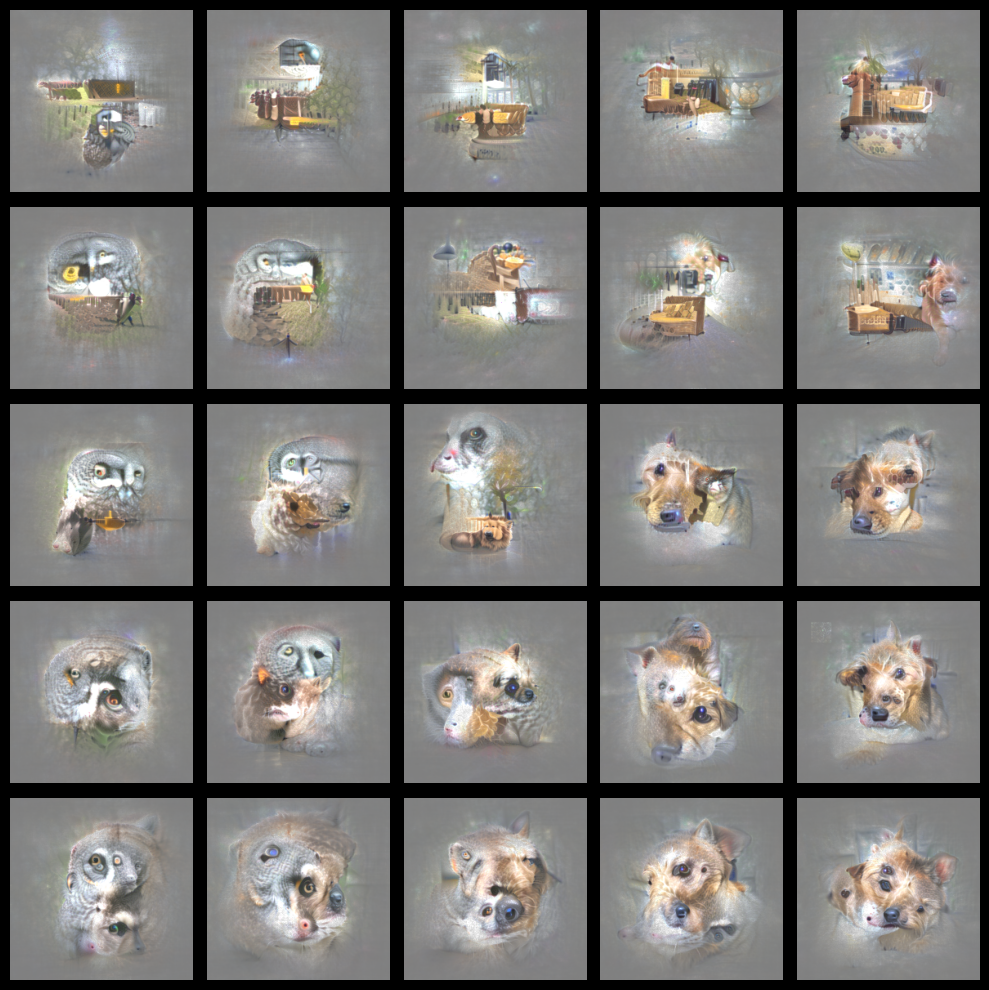

In [19]:
poles = []

for result in results:
    image = result['image'][-1]
    alpha = result['alpha'][-1]
    pole = blend(image, alpha, alphacut=90.0, mean=0, std=1., boost=1.5, bg_value=0.5)
    poles.append(pole)

plot_group(poles, cols=5)

In [16]:
results = []
target = get_pc_vector(pca_result=pca_result, pc_index=1, as_tensor=True, device='cuda')

for weight in [-1, 1]:
    obj = response_objective(
        function.embed, 
        target=target, 
        mode='reconstruct', 
        sign=1, 
        loss_type='mse',
        model_kwargs={},
    )
    
    result = fourier_ascending(
        objective_function=obj,
        magnitude_path='natural_rgb.npy',
        image_size=224,
        init_image=None,
        total_steps=128,
        learning_rate=1.0,
        lr_schedule=True,
        eta_min=0.0,
        noise=0.0,
        values_range=(0, 1.0),
        range_fn='tanh',
        nb_crops=16,
        box_size=(0.1, 1.0),
        target_norm=None,
        tv_weight=0.0,
        jitter_std=0.15,
        oversample=1, 
        reflect_pad_frac=0.0,
        device='cuda',
        verbose=True,
        save_all_steps=True,
    )
    results.append(result)

Activation: 0.0005: 100%|██████████| 128/128 [00:31<00:00,  4.07it/s]


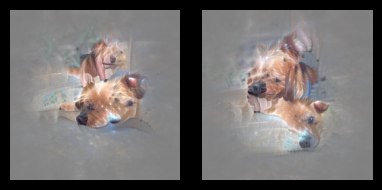

In [17]:
poles = []

for result in results:
    image = result['image'][-1]
    alpha = result['alpha'][-1]
    pole = blend(image, alpha, alphacut=90.0, mean=0, std=1., boost=1.5, bg_value=0.5)
    poles.append(pole)

plot_group(poles, cols=2)